# Machine Learning — Homework 2: Classification and Evaluation Metrics

**Course:** Machine Learning — National University of Kyiv-Mohyla Academy (NaUKMA)
**Instructor:** Dmytro Kuzmenko (kuzmenko@ukma.edu.ua)
**Module:** Week 3 — *"Learning a Boundary (Classification)"*

## Meta

- **Points:** 5 (Homework 2 of 6; homeworks total 30% of the final grade)
- **Estimated time:** 2.5–3.5 hours
- **Prerequisites:** Weeks 1–3. Python, `numpy`, `matplotlib`, `scikit-learn` (logistic regression, k-NN, confusion matrix, precision/recall/F1).
- **Deadline:** [to be announced by the instructor]
- **Submission:** one executed `.ipynb` file with the AI Use Disclosure completed.
- **Late policy:** 5 free late days across all homeworks; 1 late day = up to 24 h; after that, −25% of the maximum per additional 24 h.

## AI Use Disclosure

Policy: AI tools are allowed for homeworks, but you must disclose their use and remain responsible for every claim in your submission. On the midterm and final, AI and external help are forbidden.

- **AI tools used:** ...Claude (Anthropic)
- **Nature of assistance:** ...Claude детальніше пояснив терміни (матриця плутанини, precision/recall/специфічність/F1, ROC-крива та AUC, PR-крива та AP, поріг прийняття рішення, параметр k у k-NN, недонавчання/перенавчання, bias/variance тощо), як правильно читати графіки (криві train/validation, ROC та PR) , брати з них числа і як робити з них висновки.
- **Representative prompts or relevant interaction:** ...поясни мені як новачку в цій сфері детально завдання , всі терміни  
- **What I independently verified or changed:** ...Матеріали від Claude я застосував виключно як базову структуру та орієнтир для порівняння показників. Увесь текст до розділів (B), (D), (E), а також на дискусійні питання я складав самостійно, додатково перевіривши всі розрахунки й числа .

## Learning Objectives

- Train logistic regression and k-NN on an imbalanced two-class problem and report a coherent metric set.
- Choose an operating threshold from a precision–recall trade-off given an explicit cost scenario.
- Interpret ROC and PR curves and explain how prevalence reshapes them.
- Select k for k-NN and verify the role of feature scaling.

# Warm-up

We generate a synthetic imbalanced two-class problem: 1000 points, 2 features, about 10% positives, mild label noise, fixed seed. The splits are *stratified*, so the prevalence stays close to 10% in the training, validation, and test sets.

Prevalence (share of positives) — train: 0.108, validation: 0.110, test: 0.110


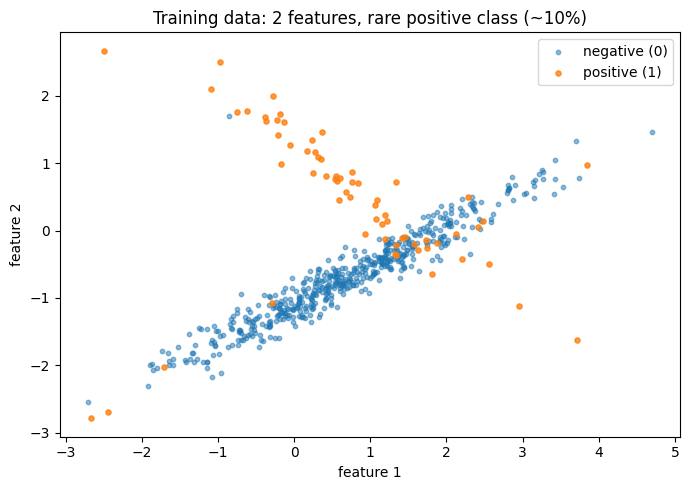

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

X, y = make_classification(
    n_samples=1000, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, flip_y=0.02, class_sep=0.7,
    weights=[0.9, 0.1], random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print("Prevalence (share of positives) — train: {:.3f}, validation: {:.3f}, test: {:.3f}".format(
    y_train.mean(), y_val.mean(), y_test.mean()))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], s=10, alpha=0.5, label="negative (0)")
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=14, alpha=0.8, label="positive (1)")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Training data: 2 features, rare positive class (~10%)")
ax.legend()
plt.tight_layout()
plt.show()

# Guided Exercise

## Task 1: Baseline and core metrics

Train logistic regression and k-NN (k = 5) on the same training split. For each model, show the confusion matrix on the test set and report accuracy, precision, recall, specificity, and F1. Also compute the accuracy of the trivial majority-class baseline.

**Experiment (A).** Fit both models and compute the metric table:

In [4]:
def metric_table(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

lr = LogisticRegression(max_iter=2000, random_state=42).fit(X_train, y_train)
knn5 = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

rows = []
for name, model in [("Logistic regression", lr), ("k-NN (k=5)", knn5)]:
    y_pred = model.predict(X_test)
    rows.append({"model": name, **metric_table(y_test, y_pred)})

df_metrics = pd.DataFrame(rows)
df_metrics

majority_acc = max(y_test.mean(), 1 - y_test.mean())
print(f"Majority-class baseline accuracy on test: {majority_acc:.3f}")

Majority-class baseline accuracy on test: 0.890


**Evidence (C).** Confusion matrices for both models:

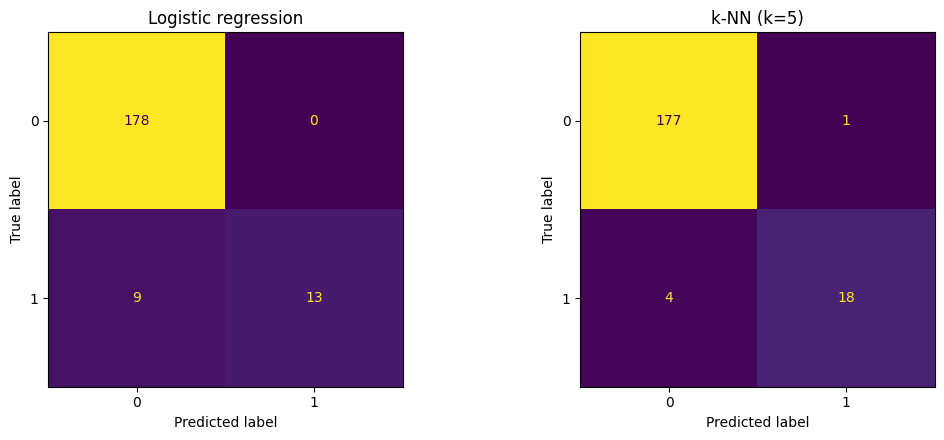

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("Logistic regression", lr), ("k-NN (k=5)", knn5)]):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Interpretation (D).** The positive class is about 10% of the test set. Why is accuracy a misleading headline metric here? Compare the two models: which metric differs most, and what does that difference mean for a screening use case where we must not miss positives?

**Your answer:**Точність (accuracy) тут оманлива, бо позитивний клас - це лише 11% тесту (22 з 200). Це значить, що навіть "тупа" модель, яка завжди відповідає "0", отримає accuracy 89%, нічого насправді не передбачаючи. Тому висока accuracy сама по собі не доводить, що модель хороша.

Якщо порівнювати дві мої моделі, найбільше відрізняється recall: у логістичної регресії він лише 0.591, а у k-NN - 0.818. Це означає, що логістична регресія пропускає 9 із 22 реальних позитивних випадків (41%!), а k-NN - лише 4 з 22 (18%). У задачі скринінгу пропущений позитивний випадок (FN) - це найгірший сценарій (наприклад, пропущений хворий пацієнт), тому саме recall тут головний показник, і за ним k-NN явно краща модель, попри те що обидві мають "гарну" accuracy.

**Decision (B).** If you had to report exactly one metric to a non-technical stakeholder, which one would you choose and why? Would the choice differ for a general-purpose classifier on balanced data?

**Your answer:**Якби я мав назвати рівно одну метрику нетехнічній людині для цього кейсу скринінгу, я б обрав recall (чутливість) — тому що саме вона напряму відповідає на питання "скільки реальних позитивних випадків ми пропустимо?".

Для звичайного класифікатора на збалансованих даних (де класи 50/50 і немає особливо "дорогої" помилки) я б, швидше за все, обрав просто accuracy — вона інтуїтивно зрозуміла нетехнічній людині ("скільки % модель вгадує правильно") і на збалансованих даних вже не буде оманливою, як у нашому випадку з перекосом класів.

**Counterfactual (E).** If the dataset were perfectly balanced (50/50), how would the relationship between accuracy and F1 change? Which of the two models would you expect to win, and why?

**Your answer:**Якщо б дані були збалансовані 50/50, то baseline (просто вгадувати мажоритарний клас) давав би лише ~50% accuracy замість 89%. У такому разі accuracy і F1 стали б набагато ближчими одна до одної, бо на збалансованих даних precision і recall зазвичай не так сильно розходяться, а accuracy перестає бути нерелевантним показником, який можна накрутити просто ігноруючи менший клас.

Щодо того, яка модель виграла б: я думаю, що k-NN, скоріш за все, все одно був би кращим або принаймні не гіршим, бо вже зараз, навіть на незбалансованих даних, у нього вищий і precision (0.947 проти 1.0, тут майже нічия), і значно вищий recall (0.818 проти 0.591). Це натякає, що межа рішення k-NN краще "вловлює" позитивний клас загалом, а не просто через дисбаланс даних.

## Task 2: Operating threshold under asymmetric costs

Cost scenario: we screen for a rare condition. Missing a positive (a false negative) is 10 times more expensive than a false alarm (a false positive). Logistic regression outputs probabilities, and the decision threshold is a free parameter. Sweep the threshold and choose the operating point.

**Experiment (A).** Sweep the decision threshold on the validation probabilities and record precision, recall, F1, and expected cost (cost = FP + 10 × FN):

In [6]:
proba_val = lr.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for t in thresholds:
    y_pred = (proba_val >= t).astype(int)
    m = metric_table(y_val, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    rows.append({"threshold": t, "precision": m["precision"], "recall": m["recall"],
                 "F1": m["F1"], "cost": fp + 10 * fn})
df_threshold = pd.DataFrame(rows)
df_threshold

,threshold,precision,recall,F1,cost
0,0.05,0.175000,0.954545,0.295775,109
1,0.10,0.377358,0.909091,0.533333,53
2,0.15,0.655172,0.863636,0.745098,40
3,0.20,0.750000,0.681818,0.714286,75
4,0.25,0.933333,0.636364,0.756757,81
5,0.30,0.933333,0.636364,0.756757,81
6,0.35,0.928571,0.590909,0.722222,91
7,0.40,0.928571,0.590909,0.722222,91
8,0.45,1.000000,0.590909,0.742857,90
9,0.50,1.000000,0.545455,0.705882,100


**Evidence (C).** Plot the trade-off curves and the cost curve:

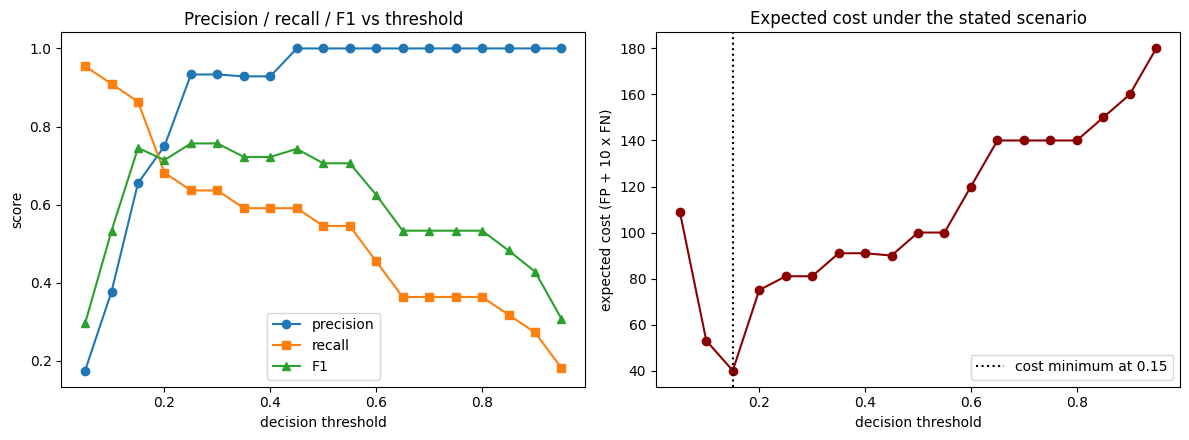

Lowest expected cost: 40 at threshold 0.15


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(df_threshold["threshold"], df_threshold["precision"], "o-", label="precision")
ax.plot(df_threshold["threshold"], df_threshold["recall"], "s-", label="recall")
ax.plot(df_threshold["threshold"], df_threshold["F1"], "^-", label="F1")
ax.set_xlabel("decision threshold")
ax.set_ylabel("score")
ax.set_title("Precision / recall / F1 vs threshold")
ax.legend()
ax = axes[1]
ax.plot(df_threshold["threshold"], df_threshold["cost"], "o-", color="darkred")
best_t = df_threshold.loc[df_threshold["cost"].idxmin(), "threshold"]
ax.axvline(best_t, color="k", ls=":", label=f"cost minimum at {best_t:.2f}")
ax.set_xlabel("decision threshold")
ax.set_ylabel("expected cost (FP + 10 x FN)")
ax.set_title("Expected cost under the stated scenario")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Lowest expected cost: {df_threshold['cost'].min():.0f} at threshold {best_t:.2f}")

**Decision (B).** Choose the operating threshold for the stated cost scenario and justify it with the numbers in the table or plots. Explain in one sentence what this threshold means operationally (what share of positives will be missed).

**Your answer:**Я обираю робочий поріг t = 0.15, бо саме при ньому очікувана вартість найменша (cost = 40) з усього перебраного діапазону - це видно і в таблиці, і на правому графіку (мінімум кривої точно на значенні 0.15). При цьому порозі recall = 0.864, тобто модель знаходить 86.4% реальних позитивних випадків, а отже, операційно, ми пропустимо приблизно 13.6% реальних позитивів (1 - 0.864). Так, ми жертвуємо частиною precision (0.655, тобто майже третина "тривог" - хибні), але у скринінгу це прийнятний компроміс, бо ціна пропущеного випадку в 10 разів вища за ціну зайвої перевірки.

**Interpretation (D).** Explain the shapes of the curves: why does precision drop sharply at very low thresholds, and why does recall collapse at high thresholds? Where is F1 maximized, and why is that not necessarily the best operating point in this scenario?



```
# This is formatted as code
```

**Your answer:**Precision різко падає при дуже низьких порогах (наприклад, 0.05), тому що модель на такому порозі позначає "1" майже все підряд - навіть слабкі, непевні сигнали. Через це вона ловить майже всіх реальних позитивних (recall = 0.955), але разом з ними хапає купу хибних спрацювань (FP), тому precision падає до 0.175 - з усіх, кого модель назвала "1", лише 17.5% дійсно позитивні.

Recall, навпаки, обвалюється при високих порогах (0.85–0.95), бо там модель стає дуже обережною - вона позначає "1" лише тоді, коли зовсім впевнена. Через це багато реальних позитивних випадків з не дуже високою ймовірністю просто відсіюються як "0" (FN росте), і recall падає аж до 0.18 при t=0.95.

F1 максимізується десь в районі t≈0.15-0.20 (F1 = 0.745-0.714) - тобто там, де precision і recall більш-менш урівноважені між собою. Але це не найкраща операційна точка для нашого сценарію, бо F1 вважає FP і FN однаково "поганими" (симетрична метрика), а в нас FN коштує в 10 разів дорожче за FP. Тому оптимальний за F1 поріг і оптимальний за cost поріг можуть майже збігтись випадково (тут вони обидва біля 0.15-0.20), але в загальному випадку це не гарантовано - треба орієнтуватись саме на функцію вартості, а не на F1.

**Counterfactual (E).** If the cost ratio were 1:1 instead of 10:1, would the operating point move up or down? If the classifier were much stronger (AUC ≈ 0.99), how would the precision–recall trade-off curve change?

**Your answer:**Якби співвідношення вартості було 1:1 замість 10:1, я б очікував, що оптимальний поріг зміститься вище (ближче до 0.5), бо тоді FP і FN "коштують" однаково, і вже немає сенсу так сильно жертвувати precision заради виявлення кожного позитивного випадку — модель просто мінімізуватиме загальну кількість помилок, а не спеціально гнатись за recall.

Якби класифікатор був значно сильнішим (AUC ≈ 0.99), крива precision-recall стала б набагато "квадратнішою" — тобто і precision, і recall залишались би близькими до 1.0 на набагато ширшому діапазоні порогів, і різкий обвал з попереднього питання (як зараз при дуже низьких/високих t) стався б лише на самих краях.З сильнішою моделлю  вибір порогу стає менш критичним — майже будь-який розумний поріг дасть і хороший precision, і хороший recall одночасно.

# Discussion Questions

Answer both questions briefly (2–4 sentences each).

**Question 1.** The validation set is used to pick the threshold. Is it legitimate to report metrics computed on the same validation set afterwards? What would you report instead?

**Your answer:**Ні, це не зовсім коректно, якщо ми підбирали поріг саме на validation set, а потім на ньому ж репортуємо фінальні метрики, це data leakage у м'якій формі: метрики будуть занадто оптимістичними, бо поріг був підігнаний саме під ці дані. Правильніше буде використати окремий test set (який модель і поріг взагалі не бачили) і репортувати фінальні precision/recall/F1/cost саме на ньому, залишивши validation тільки для підбору порогу.

**Question 2.** k-NN and logistic regression achieve similar accuracy here, yet their precision/recall profiles differ. What property of the two models explains this?

**Your answer:*Це пояснюється різницею в тому, як моделі будують межу рішення. Логістична регресія шукає єдину майже лінійну межу і схильна давати дуже "впевнені" (близькі до 0 або 1) ймовірності далеко від межі, тому при дефолтному порозі 0.5 вона часто дає високий precision, але нижчий recall . k-NN натомість дивиться на локальних сусідів і краще підлаштовується під "неправильну форму" даних (нелінійні межі, локальні скупчення класу), тому може ловити більше позитивних випадків (вищий recall) навіть якщо загальна accuracy схожа - просто помилки в обох моделей розподілені по-різному між FP і FN.*

# Challenge

## Task 3: ROC and PR curves, and a prevalence change

Plot the ROC and precision–recall curves of logistic regression on the test set and read off AUC and average precision (AP). Then simulate a deployment population with 2% prevalence and see which curve changes and which does not.

**Experiment (A).** Compute and plot both curves on the original test set:

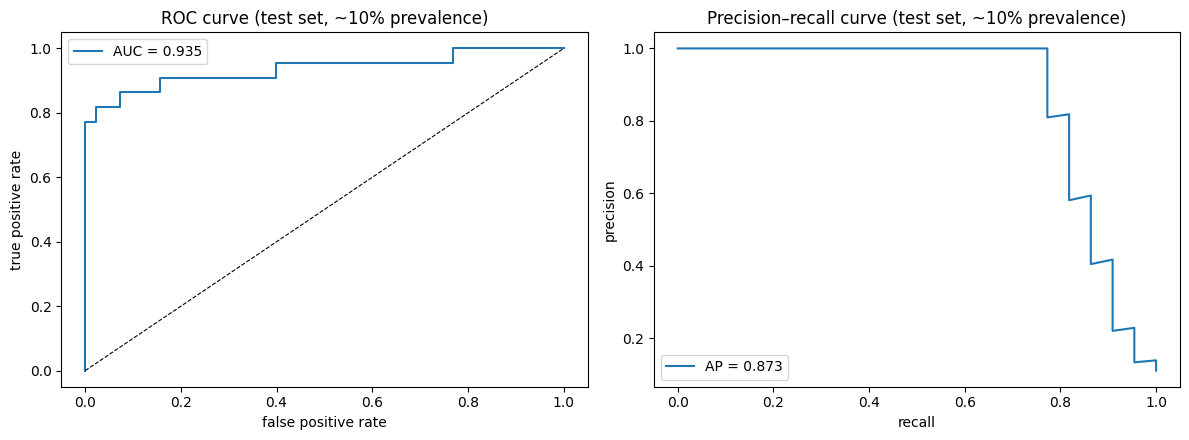

In [13]:
proba_test = lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
auc_score = roc_auc_score(y_test, proba_test)
ap_score = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve (test set, ~10% prevalence)")
ax.legend()
ax = axes[1]
ax.plot(rec, prec, label=f"AP = {ap_score:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision–recall curve (test set, ~10% prevalence)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation (D).** Interpret both curves and the two scalar summaries. What does AUC actually measure, and why is it insensitive to class balance? What does the PR curve emphasize that ROC does not?

**Your answer:**AUC = 0.935 означає, що якщо взяти випадкову позитивну і випадкову негативну людину з тесту, то з ймовірністю 93.5% модель дасть позитивній людині вищий скор ризику. AUC рахується через TPR і FPR - обидва ці показники є "частками всередині свого класу" (TPR - частка серед реальних позитивних, FPR - частка серед реальних негативних), тому AUC взагалі не залежить від того, скільки в даних позитивних, а скільки негативних - саме тому вона нечутлива до балансу класів.

PR-крива натомість напряму включає precision, а precision = TP/(TP+FP) залежить від того, скільки взагалі негативних прикладів навколо (бо чим більше негативів, тим більше потенційних FP). Тому PR-крива акцентує саме на тому, наскільки можна довіряти позитивному прогнозу моделі в реальних умовах, з урахуванням того, що позитивів мало - це саме те, що ROC не показує.

**Counterfactual (E).** Simulate the deployment population: keep all test positives and resample negatives (with replacement) so the prevalence becomes 2%. Recompute both curves and compare:

Simulated test set: n = 1100, prevalence = 0.020


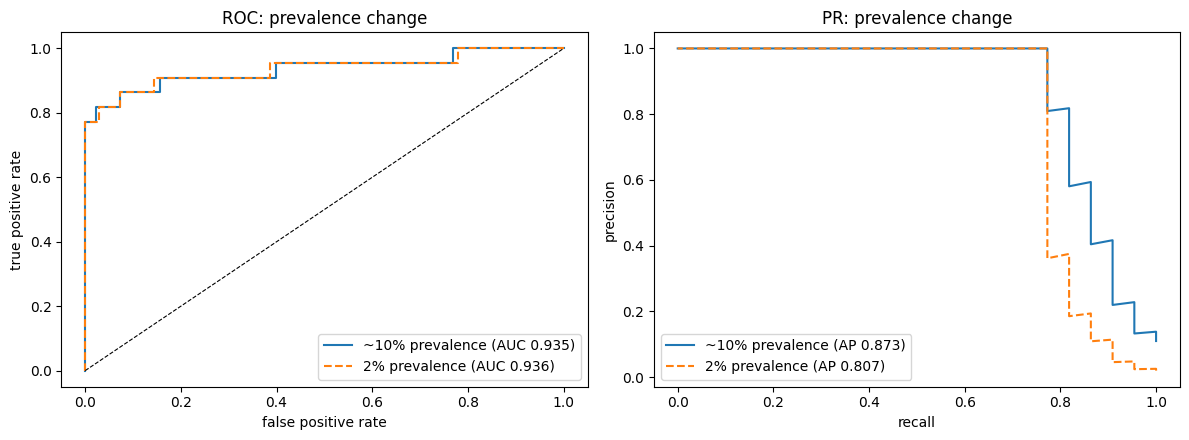

In [9]:
rng = np.random.RandomState(0)Plot the ROC and precision–recall curves of logistic regression on the test set and read off AUC and average precision (AP). Then simulate a deployment population with 2% prevalence and see which curve changes and which does not.

Experiment (A). Compute and plot both curves on the original test set:


[13]
0s
proba_test = lr.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
auc_score = roc_auc_score(y_test, proba_test)
ap_score = average_precision_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.3f\}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve (test set, ~10% prevalence)")
ax.legend()
ax = axes[1]
ax.plot(rec, prec, label=f"AP = {ap_score:.3f\}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision–recall curve (test set, ~10% prevalence)")
ax.legend()
plt.tight_layout()
plt.show()

Interpretation (D). Interpret both curves and the two scalar summaries. What does AUC actually measure, and why is it insensitive to class balance? What does the PR curve emphasize that ROC does not?

Your answer:

Counterfactual (E). Simulate the deployment population: keep all test positives and resample negatives (with replacement) so the prevalence becomes 2%. Recompute both curves and compare:


[9]
1s
$0
pos_idx = np.where(y_test == 1)[0]
neg_idx_all = np.where(y_test == 0)[0]
n_pos = len(pos_idx)
n_neg_target = int(n_pos * 0.98 / 0.02)
neg_idx = rng.choice(neg_idx_all, size=n_neg_target, replace=True)
X_test_low = np.vstack([X_test[pos_idx], X_test[neg_idx]])
y_test_low = np.hstack([np.ones(n_pos), np.zeros(n_neg_target)])
print(f"Simulated test set: n = {len(y_test_low)}, prevalence = {y_test_low.mean():.3f}")

proba_low = lr.predict_proba(X_test_low)[:, 1]
fpr_low, tpr_low, _ = roc_curve(y_test_low, proba_low)
prec_low, rec_low, _ = precision_recall_curve(y_test_low, proba_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f"~10% prevalence (AUC {auc_score:.3f})")
axes[0].plot(fpr_low, tpr_low, ls="--", label=f"2% prevalence (AUC {roc_auc_score(y_test_low, proba_low):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC: prevalence change")
axes[0].legend()
axes[1].plot(rec, prec, label=f"~10% prevalence (AP {ap_score:.3f})")
axes[1].plot(rec_low, prec_low, ls="--", label=f"2% prevalence (AP {average_precision_score(y_test_low, proba_low):.3f})")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("PR: prevalence change")
axes[1].legend()
plt.tight_layout()
plt.show()

Quantify what changed: AUC and AP before/after the prevalence change, and the precision you can expect at recall ≈ 0.8 in each population. Why does PR move while ROC barely moves? What does this imply for model selection when the deployment population is rarer than the training population?

**Your answer:**AUC практично не змінився , тоді як AP помітно впав (0.873 -> 0.807). Якщо дивитись на графіки при recall ≈ 0.8: на оригінальному тесті (10%) precision в цій точці ще досить висока, приблизно 0.85-0.9 (крива ще не почала різко падати), а на симульованій популяції (2%) при тому ж recall ≈ 0.8 precision вже помітно нижча, орієнтовно 0.5-0.55 (там, де оранжева пунктирна лінія різко обвалюється).

PR рухається, а ROC майже ні, тому що PR напряму відчуває кількість негативів через precision (а негативів у 2%-популяції відносно позитивів стало набагато більше, тож і FP стало більше при тому ж пороговому наборі помилок), а ROC (TPR/FPR) виміряні окремо всередині кожного класу і взагалі не бачать зміну співвідношення класів.

Практичний висновок для вибору моделі: якщо реальна популяція розгортання рідша (менше позитивних), ніж навчальна/тестова, не можна орієнтуватись тільки на AUC - вона виглядатиме однаково гарною, але на практиці precision моделі впаде, і буде набагато більше хибних тривог на кожен реально знайдений позитивний випадок. Тому для таких сценаріїв треба або тестувати/валідувати модель одразу на даних із реалістичним (низьким) prevalence, або дивитись саме на PR-криву і AP, а не на ROC-AUC, бо саме PR чесно показує, чого очікувати в умовах, де хвороба/подія рідкісна.

## Task 4: k-NN model selection and feature scaling

Select k for k-NN on the validation set, visualize decision boundaries in two regimes, and verify what happens when the features are standardized.

**Experiment (A).** Sweep k and record train/validation accuracy and F1:

In [15]:
ks = [1, 3, 5, 11, 31, 101]

rows = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    rows.append({
        "k": k,
        "train_acc": accuracy_score(y_train, model.predict(X_train)),
        "train_f1": f1_score(y_train, model.predict(X_train), zero_division=0),
        "val_acc": accuracy_score(y_val, model.predict(X_val)),
        "val_f1": f1_score(y_val, model.predict(X_val), zero_division=0),
    })
df_knn = pd.DataFrame(rows)
df_knn

,k,train_acc,train_f1,val_acc,val_f1
0,1,1.000000,1.000000,0.970,0.857143
1,3,0.965000,0.817391,0.970,0.850000
2,5,0.960000,0.777778,0.970,0.850000
3,11,0.958333,0.766355,0.975,0.871795
4,31,0.948333,0.693069,0.960,0.777778
5,101,0.891667,0.000000,0.890,0.000000


**Evidence (C).** F1 vs k, and decision boundaries for k = 1 and k = 31:

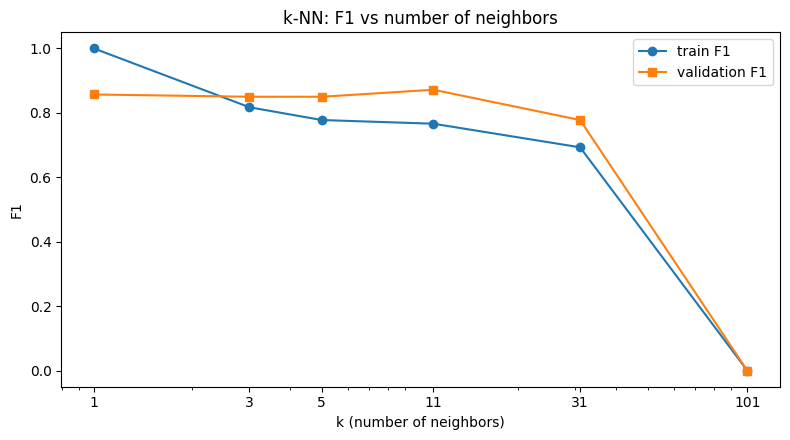

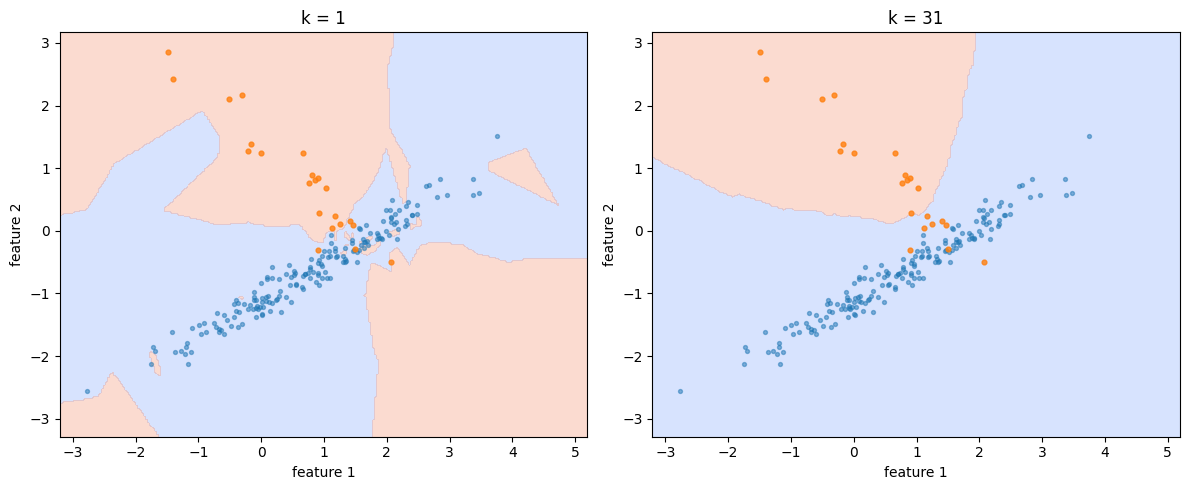

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_knn["k"], df_knn["train_f1"], "o-", label="train F1")
ax.plot(df_knn["k"], df_knn["val_f1"], "s-", label="validation F1")
ax.set_xscale("log")
ax.set_xticks(ks)
ax.set_xticklabels(ks)
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("F1")
ax.set_title("k-NN: F1 vs number of neighbors")
ax.legend()
plt.tight_layout()
plt.show()

def plot_boundary(model, ax, title):
    x0 = np.linspace(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5, 250)
    x1 = np.linspace(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5, 250)
    xx0, xx1 = np.meshgrid(x0, x1)
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    z = model.predict(grid).reshape(xx0.shape)
    ax.contourf(xx0, xx1, z, levels=[-0.5, 0.5, 1.5], alpha=0.35, cmap="coolwarm")
    ax.scatter(X_val[y_val == 0, 0], X_val[y_val == 0, 1], s=8, alpha=0.5, label="negative")
    ax.scatter(X_val[y_val == 1, 0], X_val[y_val == 1, 1], s=12, alpha=0.8, label="positive")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train), axes[0], "k = 1")
plot_boundary(KNeighborsClassifier(n_neighbors=31).fit(X_train, y_train), axes[1], "k = 31")
plt.tight_layout()
plt.show()

**Interpretation (D).** Interpret the boundary plots and the F1 curve: how does k act as a complexity control, and where do you see overfitting and underfitting?

**Your answer:**На діаграмах меж чітко видно ефект k як контролю складності: при k=1 межа рішення дуже нерівна, звивиста, з дрібними "острівцями" (наприклад, помітний маленький клаптик іншого кольору всередині основного скупчення) - модель буквально запам'ятовує кожну точку навчання, включно з шумом. При k=31 межа набагато гладша і простіша, без дрібних артефактів.

Надмірне налаштування (overfitting) видно при малих k: train F1 = 1.0 при k=1 (модель ідеально "запам'ятала" навчальні дані), але validation F1 нижчий (0.86) - є розрив між train і val. Недостатнє налаштування (underfitting) видно на іншому кінці - при k=101 обидва F1 (і train, і val) падають до 0, тобто модель настільки згладжена, що взагалі не може виявити позитивний клас (ймовірно, завжди передбачає більшість). Найкращий баланс - десь посередині, в районі k=11, де validation F1 найвищий (0.87), а розрив між train і val мінімальний.

**Decision (B).** Which k would you choose based on validation F1, and what is your reasoning? Would you expect k = 1 to be a good choice for a production model?

**Your answer:**Я б обрав k = 11, бо саме там validation F1 максимальний (0.87 з графіка), і при цьому розрив між train F1 (0.77) і val F1 (0.87) невеликий, тобто модель не перенавчена і водночас не занадто спрощена.

Ні, я не очікую, що k=1 буде гарним вибором для продакшн-моделі, попри те, що на train F1 у нього ідеальний (1.0) - це класична ознака перенавчання: модель просто запам'ятала навчальні дані, включно з шумом і викидами, і на нових, ще не бачених даних (як реальний трафік у виробництві) вона, скоріш за все, буде значно менш стабільною, ніж на валідації, бо звивиста межа дуже чутлива до конкретних точок навчання.

**Counterfactual (E).** Verify the effect of feature scaling on one k:

In [12]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)

knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print("k = 5, raw features:    val accuracy {:.3f}, val F1 {:.3f}".format(
    accuracy_score(y_val, knn_raw.predict(X_val)),
    f1_score(y_val, knn_raw.predict(X_val), zero_division=0)))
print("k = 5, scaled features: val accuracy {:.3f}, val F1 {:.3f}".format(
    accuracy_score(y_val, knn_scaled.predict(X_val_s)),
    f1_score(y_val, knn_scaled.predict(X_val_s), zero_division=0)))

k = 5, raw features:    val accuracy 0.970, val F1 0.850
k = 5, scaled features: val accuracy 0.980, val F1 0.900


What changed after scaling and why? For which family of models (distance-based vs tree-based) does scaling matter more, and how would the decision boundary change if one feature had a much larger range than the other?

**Your answer:**З наведених чисел: k=5, необроблені ознаки - val accuracy 0.970, val F1 0.850; k=5, масштабовані ознаки - val accuracy 0.980, val F1 0.900. Після масштабування обидва показники покращились (accuracy +0.01, F1 +0.05). Причина в тому, що k-NN базується на відстані між точками (зазвичай євклідовій), а якщо одна ознака має набагато більший діапазон значень, ніж інша (наприклад, одна від 0 до 1000, а інша від 0 до 1), то відстань буде практично повністю визначатись тією ознакою з більшим діапазоном - друга ознака фактично "ігнорується" моделлю, навіть якщо вона важлива для класифікації.

Масштабування має набагато більше значення для моделей на основі відстані (k-NN, SVM з RBF-ядром, кластеризація), бо вони напряму рахують відстані/подібність між точками. Для моделей на основі дерева (Decision Tree, Random Forest, Gradient Boosting) масштабування майже не важливе, бо дерева розбивають простір ознак по порогах для кожної ознаки окремо (наприклад, "ознака 1 > 5"), і масштаб конкретної ознаки не впливає на те, як дерево обирає точку розбиття.

Якби одна ознака мала набагато більший діапазон, ніж інша, межа прийняття рішення (без масштабування) стала б майже перпендикулярною до осі "великої" ознаки - тобто модель фактично класифікувала б, дивлячись лише на цю одну ознаку, ігноруючи другу, навіть якщо друга ознака насправді краще розділяє класи. Після масштабування обидві ознаки роблять внесок у відстань пропорційно до своєї реальної інформативності, а не до випадкового масштабу вимірювання.

## Takeaways

- With a 10% prevalence, accuracy is dominated by the majority class; report precision, recall, specificity, and F1 together.
- The decision threshold is a business parameter: with asymmetric costs, pick the operating point on the precision–recall trade-off, not the default 0.5.
- ROC is prevalence-insensitive; PR is not. Match the curve (and the test set) to the deployment population.
- k-NN complexity is controlled by k; scaling changes distances, so it changes the model.